<a href="https://colab.research.google.com/github/malehzja/final_lis4693/blob/main/final-project/FinalProject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Final Project**
# Task 1: Text Analysis and Visualization


Choose a text dataset containing at least 1,000 text documents with associated labels or categories. Each dataset must contain a text column (documents, posts, reviews, etc.).


---


The dataset chosen was a IMDB tv show review dataset from Kaggle consisting of over 8,000 reviews.

# Import Libraries

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

# Load Data

Importing dataset from shared Github Repository "Final Project"

In [2]:
import requests
import io

url = "https://raw.githubusercontent.com/malehzja/final_lis4693/refs/heads/main/final-project/imdb_tvshows.csv"
response = requests.get(url)
response.raise_for_status()
text = response.text

df = pd.read_csv(io.StringIO(text), sep=',')  #File is comma delimmited
print(df.head())

   Unnamed: 0  Rating (out of 10)  \
0           0                   9   
1           1                  10   
2           2                  10   
3           3                   9   
4           4                   9   

                                              Review    Show ID   Review ID  
0  Andor was every bit as good as I was hoping fo...  tt9253284  rw10514299  
1  Wow. I just finished episode 12 of the first s...  tt9253284   rw8690571  
2  Andor Season 2 is the best Star Wars Show ever...  tt9253284  rw10514285  
3  There were a few episodes I didn't like in bot...  tt9253284  rw10514788  
4  Didnt like the new movies and even Mandalorian...  tt9253284   rw8665236  


In [3]:
print(df.columns)

Index(['Unnamed: 0', 'Rating (out of 10)', 'Review', 'Show ID', 'Review ID'], dtype='object')


# Choose any two methods you have learnt in this course to perform text analysis on your dataset:

Topic Modeling  
Network Analysis  
Sentiment Analysis  
Perform descriptive analysis and visualize using Altair [refer to Info Visualization module]

---

Sentiment Analysis and Text Network Analysis will be used.

# 1️⃣ **Sentiment Analysis**

## Create new dataframe with 'Unnamed: 0' and 'Review' fields

In [17]:
df_subset = df[['Unnamed: 0', 'Review']].copy()

## Remove non-alphabet characters

In [18]:
df_subset['Review'] = df_subset['Review'].str.replace("[^a-zA-Z#]", "   ")

## Convert to lowercase

In [19]:
df_subset['Review'] = df_subset['Review'].str.casefold()
print(df_subset.head(10))

   Unnamed: 0                                             Review
0           0  andor was every bit as good as i was hoping fo...
1           1  wow. i just finished episode 12 of the first s...
2           2  andor season 2 is the best star wars show ever...
3           3  there were a few episodes i didn't like in bot...
4           4  didnt like the new movies and even mandalorian...
5           5  i'll say it again: andor is one of the best pi...
6           6  this is, minute for minute, some of the best t...
7           7  andor is why i pay my disney+ subscription. th...
8           8  i am going to put it plain and simple.  this s...
9           9  this is the show anyone who grew up with class...


## Generate polarity scores

In [ ]:
df1 = pd.DataFrame()
df1['Review'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0

In [ ]:
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

results = []

for _, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Review']) # Access by column name for clarity and robustness

    results.append({
        'Unnamed: 0': row['Unnamed: 0'],
        'Review': row['Review'],
        'sentiment_score': scores['compound']
    })

t_df_cleaned = pd.DataFrame(results)

print(t_df_cleaned.head(10))

Processing sentiment analysis...
   Unnamed: 0                                             Review  \
0           0  andor was every bit as good as i was hoping fo...   
1           1  wow. i just finished episode 12 of the first s...   
2           2  andor season 2 is the best star wars show ever...   
3           3  there were a few episodes i didn't like in bot...   
4           4  didnt like the new movies and even mandalorian...   
5           5  i'll say it again: andor is one of the best pi...   
6           6  this is, minute for minute, some of the best t...   
7           7  andor is why i pay my disney+ subscription. th...   
8           8  i am going to put it plain and simple.  this s...   
9           9  this is the show anyone who grew up with class...   

   sentiment_score  
0           0.9842  
1           0.9564  
2           0.9929  
3          -0.8118  
4           0.0382  
5           0.9732  
6           0.6428  
7           0.9772  
8           0.9456  
9       

# Merge Dataframes
Merge this output dataframe `t_df_cleaned` with the input dataframe `df` using the field `id`. This dataframe merge operation in Python is conceptually similar to performing a join on two database tables.

The code snippet below performs this merge operation and prints the top ten rows of the resulting dataframe.

In [ ]:
df_output = pd.merge(df, t_df_cleaned, on='Unnamed: 0', how='inner')
print(df_output.head(10))

   Unnamed: 0  Rating (out of 10)  \
0           0                   9   
1           1                  10   
2           2                  10   
3           3                   9   
4           4                   9   
5           5                   9   
6           6                   9   
7           7                   9   
8           8                   8   
9           9                   7   

                                            Review_x    Show ID   Review ID  \
0  Andor was every bit as good as I was hoping fo...  tt9253284  rw10514299   
1  Wow. I just finished episode 12 of the first s...  tt9253284   rw8690571   
2  Andor Season 2 is the best Star Wars Show ever...  tt9253284  rw10514285   
3  There were a few episodes I didn't like in bot...  tt9253284  rw10514788   
4  Didnt like the new movies and even Mandalorian...  tt9253284   rw8665236   
5  I'll say it again: Andor is one of the best pi...  tt9253284  rw10514474   
6  This is, minute for minute, some of 

## Visualize Sentiment Analysis Output

In [ ]:
df_output[["sentiment_score"]].describe()

,sentiment_score
count,8319.000000
mean,0.555964
std,0.616758
min,-0.998300
25%,0.408000
50%,0.881800
75%,0.968600
max,0.999700


Results: On average, the reviews were moderately positive.

In [ ]:
print(df['Show ID'].unique())

['tt9253284' 'tt3581920' 'tt5834204' 'tt4236770' 'tt9288030' 'tt2442560'
 'tt13443470' 'tt8111088' 'tt5180504' 'tt13406094']


**Show Names (manually looked up)**   
tt9253284 = Andor   
tt3581920 = The Last of Us    
tt5834204 = The Handmaids Tale  
tt4236770 = Yellowstone   
tt9288030 = Reacher   
tt2442560 = Peaky Blinders    
tt13443470 = Wednesday    
tt8111088 = The Mandalorian   
tt5180504 = The Witcher   
tt13406094 = The White Lotus


In [ ]:
id_to_title = {
    "tt9253284": "Andor",
    "tt3581920": "The Last of Us",
    "tt5834204": "The Handmaid's Tale",
    "tt4236770": "Yellowstone",
    "tt9288030": "Reacher",
    "tt2442560": "Peaky Blinders",
    "tt13443470": "Wednesday",
    "tt8111088": "The Mandalorian",
    "tt5180504": "The Witcher",
    "tt13406094": "The White Lotus"
}

<Axes: title={'center': 'sentiment_score'}, xlabel='TV Show', ylabel='Mean Sentiment Score'>

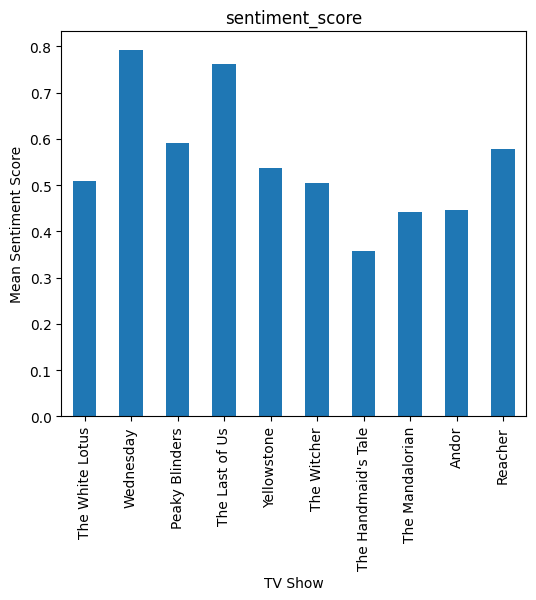

In [ ]:
dfg = df_output.groupby(['Show ID'])['sentiment_score'].mean()

dfg.index = dfg.index.map(id_to_title)

dfg.plot(kind='bar', title='sentiment_score', ylabel='Mean Sentiment Score',
         xlabel='TV Show', figsize=(6, 5))

Results:
The Handmaid's Tale had the lowest sentiment scores and Wednesday had the highest. This means that on average people had more positive things to say about Wednesday and more negative about things to say about The Handsmaid's Tale.